# Demanda residual de electricidad en España

### Se combinan dos datasets: consumo y producción solar

Pregunta y objetivos

Un operador del sistema eléctrico quiere anticipar cuánta energía deberá cubrir con fuentes distintas de la solar en los próximos días.

y₁ = demanda_gwh (consumo diario)
y₂ = solar_gwh (producción solar diaria)
Demanda residual = ŷ₁ − ŷ₂ (GWh a cubrir con otras fuentes)

In [14]:
%pip install pandas numpy matplotlib seaborn scikit-learn holidays joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# --- Librerías de siempre ---
from pathlib import Path          # rutas de ficheros que funcionan igual en Windows, Mac y Linux
import numpy as np                # cálculo numérico (redondeos, arrays, NaN...)
import pandas as pd               # tablas (DataFrames): cargar CSV, seleccionar columnas...
import matplotlib.pyplot as plt   # gráficos básicos
import seaborn as sns             # gráficos bonitos encima de matplotlib
import holidays                   # calendario de festivos (España, Francia, Alemania, etc.)
import joblib                     # guardar y cargar modelos de machine learning (para no reentrenarlos cada vez)

# --- scikit-learn: los dos modelos de regresión y la métrica de evaluación de este proyecto ---
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error   # MAE: error medio en las unidades del problema (GWh)

# Estilo de los gráficos y opciones de pandas para que las tablas se lean bien
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

# Carpeta donde están los CSV
DATA_DIR = Path("data")
print("Carpeta de datos:", DATA_DIR.resolve())
print("Ficheros:", sorted(p.name for p in DATA_DIR.glob("*.csv")))

Carpeta de datos: C:\Users\LENOVO\Documents\GitHub\Spain_elctricity\data
Ficheros: ['demanda_electrica_espana.csv', 'solar_espana.csv']


### Paso 1: Datos y pregunta
¿Cuántos GWh debe un operario cubrir con otras fuentes distintas a la solar?

In [16]:
# 1. Carga de los dos CSV y primer vistazo (columnas, tamaño y tipos)
df_dem = pd.read_csv(DATA_DIR / "demanda_electrica_espana.csv")
df_sol = pd.read_csv(DATA_DIR / "solar_espana.csv")

print("Demanda:", len(df_dem), "| Columnas:", list(df_dem.columns))
print(df_dem.head().to_string())
print("\nProducción:", len(df_sol), "| Columnas:", list(df_sol.columns))
print(df_sol.head().to_string())

df_dem.info()
df_sol.info()

Demanda: 2096 | Columnas: ['fecha', 'demanda_gwh', 'temperatura_madrid']
        fecha  demanda_gwh  temperatura_madrid
0  2021-01-01        608.7                 3.6
1  2021-01-02        680.4                 1.7
2  2021-01-03        684.5                 1.4
3  2021-01-04        793.6                 1.6
4  2021-01-05        806.6                -0.3

Producción: 1366 | Columnas: ['fecha', 'solar_gwh', 'radiacion_madrid']
        fecha  solar_gwh  radiacion_madrid
0  2023-01-01       34.9              7.52
1  2023-01-02       31.9              5.49
2  2023-01-03       54.0              8.85
3  2023-01-04       58.5              9.35
4  2023-01-05       58.5              9.35
<class 'pandas.DataFrame'>
RangeIndex: 2096 entries, 0 to 2095
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fecha               2096 non-null   str    
 1   demanda_gwh         2096 non-null   float64
 2   temperatura_madrid

In [17]:
# 2. Fecha a datetime, orden cronológico e índice limpio
for d in (df_dem, df_sol):
    d["fecha"] = pd.to_datetime(d["fecha"])
    d.sort_values("fecha", inplace=True)
    d.reset_index(drop=True, inplace=True)


def revisar_fechas(df_in, nombre):
    """Comprueba que el calendario de una serie diaria no tenga huecos ni fechas duplicadas, condición necesaria para que los lags (shift) apunten siempre al día correcto."""
    rango = pd.date_range(df_in["fecha"].min(), df_in["fecha"].max(), freq="D")
    huecos = rango.difference(df_in["fecha"])
    print(f"{nombre}: {df_in['fecha'].min().date()} -> {df_in['fecha'].max().date()} | "
          f"filas: {len(df_in)} | fechas duplicadas: {df_in['fecha'].duplicated().sum()} | "
          f"días que faltan: {len(huecos)}")


# 3. Revisión de rango, fechas duplicadas y huecos en el calendario
revisar_fechas(df_dem, "Demanda")
revisar_fechas(df_sol, "Solar")

# 4. Unión por fecha: inner join = solo el periodo en que se solapan ambas series
df = df_dem.merge(df_sol, on="fecha", how="inner")

# 5. Variable derivada para el panel de control (demanda residual real)
df["residual_gwh"] = df["demanda_gwh"] - df["solar_gwh"]

print(f"\nDataset unido: {df.shape} | {df['fecha'].min().date()} -> {df['fecha'].max().date()}")
df.head()

Demanda: 2021-01-01 -> 2026-09-27 | filas: 2096 | fechas duplicadas: 0 | días que faltan: 0
Solar: 2023-01-01 -> 2026-09-27 | filas: 1366 | fechas duplicadas: 0 | días que faltan: 0

Dataset unido: (1366, 6) | 2023-01-01 -> 2026-09-27


,fecha,demanda_gwh,temperatura_madrid,solar_gwh,radiacion_madrid,residual_gwh
0,2023-01-01,506.4,8.5,34.9,7.52,471.5
1,2023-01-02,621.6,9.0,31.9,5.49,589.7
2,2023-01-03,677.1,7.0,54.0,8.85,623.1
3,2023-01-04,689.2,5.0,58.5,9.35,630.7
4,2023-01-05,671.3,4.7,58.5,9.35,612.8


### Paso 2: Limpieza

Resultado del paso 1: ambas series tienen el calendario completo (0 huecos, 0 duplicados) y el solape es 2023-01-01 → 2026-09-27 (1.366 días). Por tanto shift(7) apunta siempre al día correcto.

Criterio: en series temporales no se borran filas (se crearían huecos y shift dejaría de funcionar). Los valores erróneos se marcan como NaN y se interpolan. Por eso "filas antes y después" puede ser igual, y lo documentamos como valores corregidos.

In [18]:
def marcar_atipicos(serie, ventana=15, umbral=5):
    """Señala los valores que se alejan de su entorno temporal más de `umbral` desviaciones robustas (mediana móvil ± MAD), útil para detectar picos o caídas anómalas sin que la estacionalidad dispare falsos positivos."""
    mediana_movil = serie.rolling(ventana, center=True, min_periods=5).median()
    desviacion = serie - mediana_movil
    z_robusto = 0.6745 * desviacion / desviacion.abs().median()
    return z_robusto.abs() > umbral


def diagnostico(df_in, nombre, col_obj, col_exo):
    """Imprime un resumen de calidad de datos: nulos, duplicados, estadísticos descriptivos, valores repetidos consecutivos y atípicos (vía marcar_atipicos)."""
    print(f"===== {nombre} | filas: {len(df_in)} =====")
    print("Nulos:\n", df_in.isna().sum().to_string())
    print("Filas duplicadas completas:", df_in.duplicated().sum())
    print(df_in.describe().round(2).to_string())

    # Valores idénticos al día anterior (posible relleno, como 4 y 5 de enero de 2023 en solar)
    for c in (col_obj, col_exo):
        rep = (df_in[c].diff() == 0)
        print(f"{c}: días idénticos al anterior = {rep.sum()}")

    # Atípicos respecto a la mediana móvil centrada de 15 días
    for c in (col_obj, col_exo):
        print(f"{c}: atípicos (|z robusto| > 5) = {marcar_atipicos(df_in[c]).sum()}")


diagnostico(df_dem, "Demanda", "demanda_gwh", "temperatura_madrid")
diagnostico(df_sol, "Solar", "solar_gwh", "radiacion_madrid")

# Valores imposibles
print("\nDemanda <= 0:", (df_dem["demanda_gwh"] <= 0).sum())
print("Temperatura fuera de [-20, 50] ºC:",
      (~df_dem["temperatura_madrid"].between(-20, 50)).sum())
print("Solar < 0:", (df_sol["solar_gwh"] < 0).sum())
print("Radiación < 0:", (df_sol["radiacion_madrid"] < 0).sum())

===== Demanda | filas: 2096 =====
Nulos:
 fecha                 0
demanda_gwh           0
temperatura_madrid    0
Filas duplicadas completas: 0
                     fecha  demanda_gwh  temperatura_madrid
count                 2096      2096.00             2096.00
mean   2023-11-14 12:00:00       694.06               16.25
min    2021-01-01 00:00:00       403.30               -3.20
25%    2022-06-08 18:00:00       651.10                9.20
50%    2023-11-14 12:00:00       693.05               15.30
75%    2025-04-21 06:00:00       742.25               23.42
max    2026-09-27 00:00:00       877.00               33.70
std                    NaN        71.35                8.48
demanda_gwh: días idénticos al anterior = 4
temperatura_madrid: días idénticos al anterior = 64
demanda_gwh: atípicos (|z robusto| > 5) = 3
temperatura_madrid: atípicos (|z robusto| > 5) = 0
===== Solar | filas: 1366 =====
Nulos:
 fecha               0
solar_gwh           0
radiacion_madrid    0
Filas duplicadas co

#### Interpretación del diagnóstico

Los datos están limpios en lo estructural (0 nulos, 0 duplicados, 0 valores imposibles, rangos físicamente razonables). Solo hay tres cosas que decidir:

| Hallazgo | Veredicto | Acción |
|---|---|---|
| Demanda: 3 atípicos | Pocos, probablemente festivos o días anómalos (Navidad, 1-ene, etc.) | Inspeccionar antes de corregir |
| Temperatura: 64 días idénticos al anterior | Normal: está redondeada a 0,1 ºC y varios días seguidos pueden coincidir | No tocar |
| Radiación: 26 atípicos | Falso positivo casi seguro: la radiación cambia mucho de un día a otro (nubes) y el z robusto es sensible aquí | No corregir |
| Solar y demanda: 4 días idénticos al anterior | Coinciden con el patrón visto (4-5 ene 2023: 58,5 y 9,35 repetidos). Probable relleno de la fuente | Inspeccionar

#### Inspección de lo marcado

In [19]:
# Demanda: los 3 atípicos, con día de la semana
m = marcar_atipicos(df_dem["demanda_gwh"])
print("DEMANDA atípicos:")
print(df_dem.loc[m].assign(dia=lambda d: d["fecha"].dt.day_name()).to_string())

# Radiación: los 26, resumidos por mes
m = marcar_atipicos(df_sol["radiacion_madrid"])
print("\nRADIACIÓN atípicos por mes:")
print(df_sol.loc[m, "fecha"].dt.to_period("M").value_counts().sort_index().to_string())

# Días repetidos exactos (demanda y solar), con el valor para comparar
for df_serie, c in ((df_dem, "demanda_gwh"), (df_sol, "solar_gwh")):
    idx = df_serie.index[df_serie[c].diff() == 0]
    print(f"\n{c}: fechas repetidas")
    print(df_serie.loc[idx, ["fecha", c]].to_string())

DEMANDA atípicos:
          fecha  demanda_gwh  temperatura_madrid     dia
1578 2025-04-28        403.3                15.8  Monday
1654 2025-07-13        615.5                25.9  Sunday
2032 2026-07-26        656.5                24.0  Sunday

RADIACIÓN atípicos por mes:
fecha
2023-03    1
2023-05    1
2023-06    2
2023-09    3
2023-10    1
2024-03    2
2024-05    1
2024-06    4
2025-04    1
2025-06    1
2025-09    2
2026-03    3
2026-04    1
2026-05    2
2026-08    1
Freq: M

demanda_gwh: fechas repetidas
          fecha  demanda_gwh
588  2022-08-12        750.8
636  2022-09-29        663.8
803  2023-03-15        669.7
1195 2024-04-10        668.3

solar_gwh: fechas repetidas
          fecha  solar_gwh
4    2023-01-05       58.5
357  2023-12-24       80.1
1078 2025-12-14       81.0
1300 2026-07-24      251.3


### Cierre del paso 2: limpieza

Los datos están casi limpios y solo hay que corregir un valor.

| Hallazgo | Veredicto | Acción |
|---|---|---|
| Demanda 2025-04-28: 403,3 GWh (lunes) | Coincide con el apagón ibérico del 28 de abril de 2025. Es un dato real, pero es un evento único e impredecible con estos datos | Corregir |
| Demanda 2025-07-13 y 2026-07-26 (domingos) | Domingos de verano con temperatura moderada; el detector los marca porque compara con la mediana de 15 días, que mezcla laborables y fines de semana | Dejar |
| Radiación: 26 atípicos repartidos por 15 meses distintos | Variación meteorológica normal (días nublados entre días soleados) | Dejar |
| 4 días repetidos en demanda y 4 en solar | Fechas sueltas, no consecutivas; con un decimal y 1.300-2.000 días, alguna coincidencia exacta es esperable | Dejar |

In [20]:
n_dem_antes, n_sol_antes = len(df_dem), len(df_sol)

# Apagón ibérico (28-abr-2025): se marca como NaN y se rellena con el mismo día de la semana
fecha_apagon = pd.Timestamp("2025-04-28")
festivos_excluidos = {pd.Timestamp("2025-04-21")}  # Lunes de Pascua (festivo en varias CCAA)

df_dem.loc[df_dem["fecha"] == fecha_apagon, "demanda_gwh"] = np.nan

# Lunes vecinos (±1 y ±2 semanas), sin festivos
vecinos = [fecha_apagon + pd.Timedelta(weeks=k) for k in (-2, -1, 1, 2)]
vecinos = [f for f in vecinos if f not in festivos_excluidos]
ref = df_dem.loc[df_dem["fecha"].isin(vecinos), ["fecha", "demanda_gwh"]]
assert len(ref) >= 3 and ref["demanda_gwh"].notna().all(), "Faltan lunes vecinos válidos"
print("Lunes de referencia:\n", ref.to_string(index=False))

df_dem.loc[df_dem["fecha"] == fecha_apagon, "demanda_gwh"] = ref["demanda_gwh"].median()

# Reconstruir el dataset unido con los datos limpios
df = df_dem.merge(df_sol, on="fecha", how="inner")
df["residual_gwh"] = df["demanda_gwh"] - df["solar_gwh"]

print(f"\nDemanda: {n_dem_antes} filas antes -> {len(df_dem)} después | valores corregidos: 1")
print(f"Solar:   {n_sol_antes} filas antes -> {len(df_sol)} después | valores corregidos: 0")
print("Nulos restantes:", int(df_dem.isna().sum().sum() + df_sol.isna().sum().sum()))
print("Demanda 2025-04-28 tras corregir:",
      df_dem.loc[df_dem["fecha"] == fecha_apagon, "demanda_gwh"].iloc[0])

Lunes de referencia:
      fecha  demanda_gwh
2025-04-14        663.4
2025-05-05        648.3
2025-05-12        643.3

Demanda: 2096 filas antes -> 2096 después | valores corregidos: 1
Solar:   1366 filas antes -> 1366 después | valores corregidos: 0
Nulos restantes: 0
Demanda 2025-04-28 tras corregir: 648.3


**Corrección aplicada:** se probó primero una interpolación lineal entre el día anterior y el siguiente pero el resultado (565,9 GWh) quedaba demasiado bajo para un lunes, porque promediaba un domingo (demanda baja) con un martes laborable. Se sustituyó por la mediana de los lunes de semanas vecinas, sin festivos, dando 648,3 GWh — un valor coherente con el resto de lunes de esa época del año.

### Paso 3: EDA

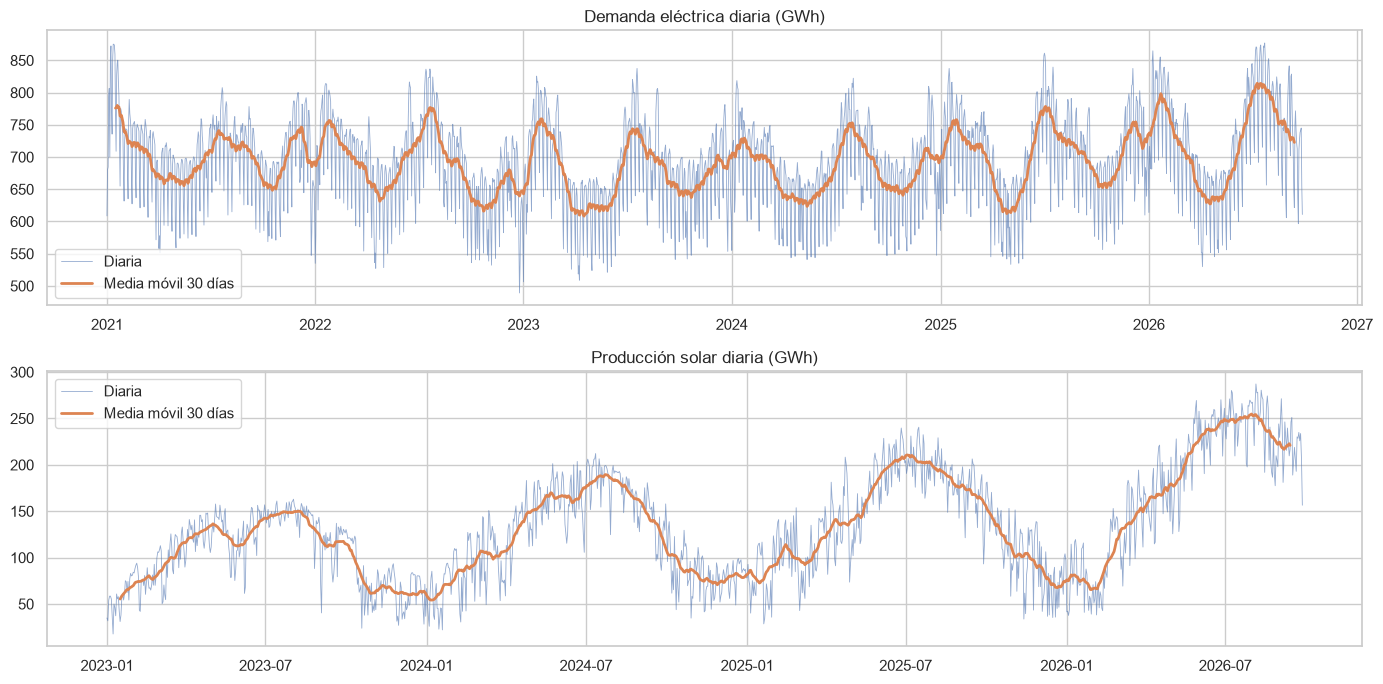

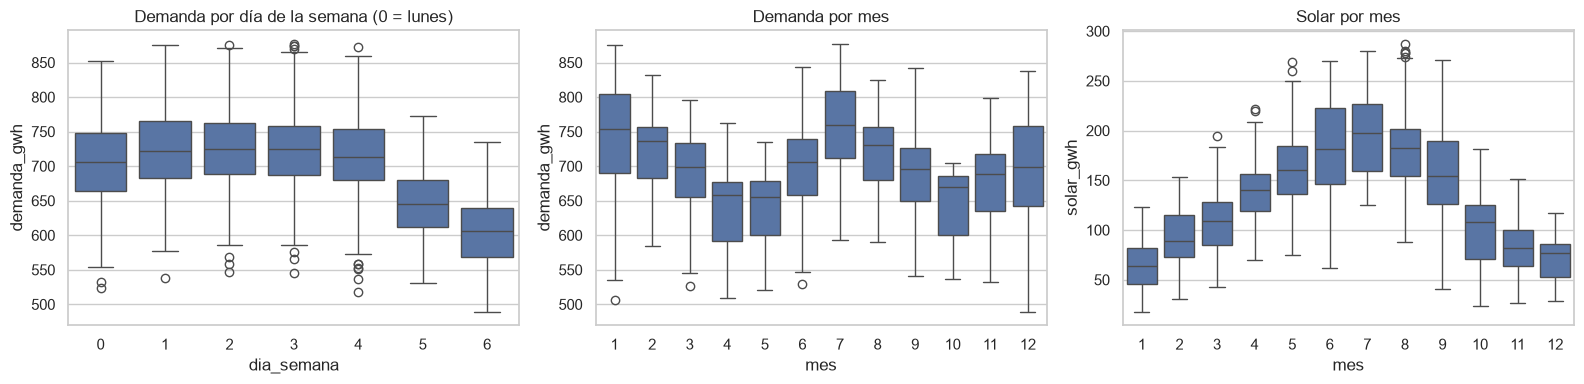

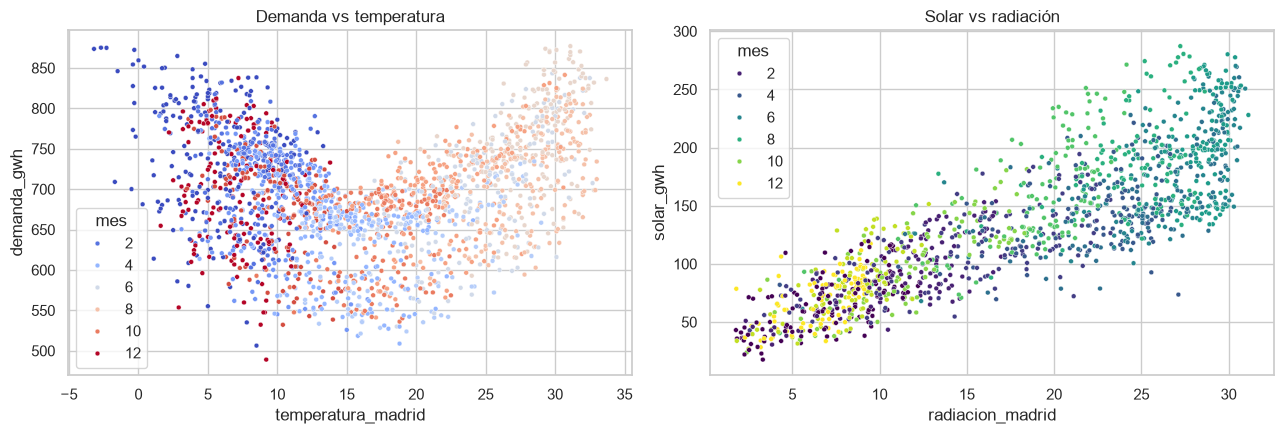

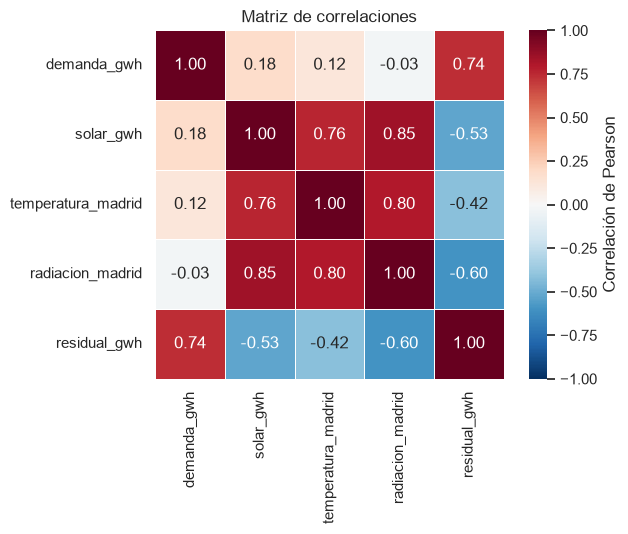

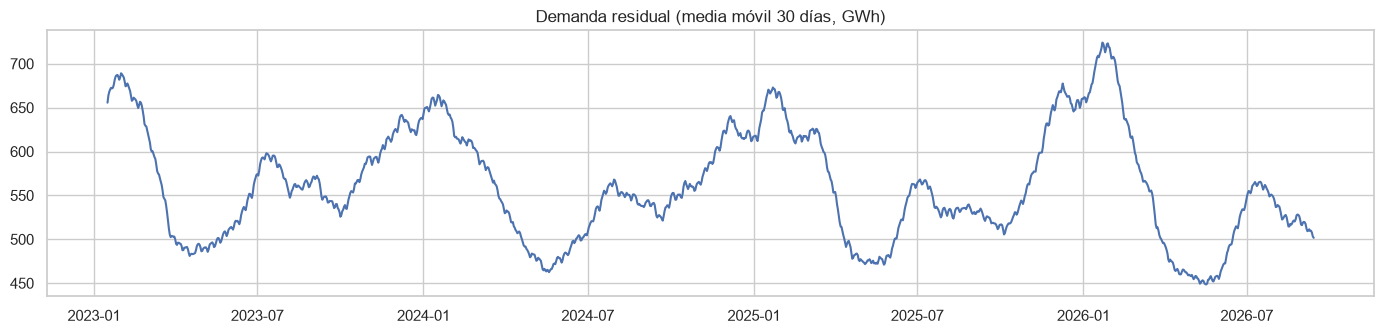

In [26]:
# Variables de calendario (se conocen siempre de antemano)
for d in (df_dem, df_sol, df):
    d["dia_semana"] = d["fecha"].dt.dayofweek   # 0 = lunes
    d["mes"] = d["fecha"].dt.month

# 1) Serie temporal: demanda y solar con media móvil de 30 días
fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
ax[0].plot(df_dem["fecha"], df_dem["demanda_gwh"], lw=0.6, alpha=0.6, label="Diaria")
ax[0].plot(df_dem["fecha"], df_dem["demanda_gwh"].rolling(30, center=True).mean(),
           lw=2, label="Media móvil 30 días")
ax[0].set_title("Demanda eléctrica diaria (GWh)"); ax[0].legend()

ax[1].plot(df_sol["fecha"], df_sol["solar_gwh"], lw=0.6, alpha=0.6, label="Diaria")
ax[1].plot(df_sol["fecha"], df_sol["solar_gwh"].rolling(30, center=True).mean(),
           lw=2, label="Media móvil 30 días")
ax[1].set_title("Producción solar diaria (GWh)"); ax[1].legend()
plt.tight_layout(); plt.show()

# 2) Estacionalidad: semanal (demanda) y anual (ambas)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=df_dem, x="dia_semana", y="demanda_gwh", ax=ax[0])
ax[0].set_title("Demanda por día de la semana (0 = lunes)")
sns.boxplot(data=df_dem, x="mes", y="demanda_gwh", ax=ax[1])
ax[1].set_title("Demanda por mes")
sns.boxplot(data=df_sol, x="mes", y="solar_gwh", ax=ax[2])
ax[2].set_title("Solar por mes")
plt.tight_layout(); plt.show()

# 3) Relación con las variables meteorológicas
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(data=df_dem, x="temperatura_madrid", y="demanda_gwh",
                hue="mes", palette="coolwarm", s=12, ax=ax[0])
ax[0].set_title("Demanda vs temperatura")
sns.scatterplot(data=df_sol, x="radiacion_madrid", y="solar_gwh",
                hue="mes", palette="viridis", s=12, ax=ax[1])
ax[1].set_title("Solar vs radiación")
plt.tight_layout(); plt.show()

# 4) Correlaciones: mapa de calor
cols_corr = ["demanda_gwh", "solar_gwh", "temperatura_madrid", "radiacion_madrid", "residual_gwh"]
corr = df[cols_corr].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",        # muestra el valor dentro de cada celda
    cmap="RdBu_r", vmin=-1, vmax=1, center=0,  # diverging: azul (negativa) - blanco (0) - rojo (positiva)
    square=True, linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Correlación de Pearson"},
    ax=ax,
)
ax.set_title("Matriz de correlaciones")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(df["fecha"], df["residual_gwh"].rolling(30, center=True).mean())
ax.set_title("Demanda residual (media móvil 30 días, GWh)")
plt.tight_layout(); plt.show()

#### Cierre del paso 3

- **Demanda:** ciclo semanal (fin de semana −10-15 %) y estacionalidad anual bimodal (picos en enero y julio). Relación en forma de "U" con la temperatura, invisible en la correlación de Pearson (r=0,12) porque no es lineal, pero muy clara en el gráfico de dispersión.
- **Solar:** estacional (máximo en verano, mínimo en invierno), con fuerte correlación con la radiación (r=0,85) y una tendencia creciente entre años por la nueva potencia instalada.
- **Demanda vs. solar:** correlación casi nula (r=0,18). La solar aporta poco para predecir la demanda directamente, lo que respalda no usarla como variable de ese modelo.
- **Demanda residual:** dominada por la demanda (r=0,74) y reducida claramente por la radiación (r=−0,60). Su media móvil muestra picos de invierno cada vez más altos (690→725 GWh entre 2023 y 2026) y valles cada vez más bajos (485→455 GWh): el hueco a cubrir en invierno no mejora, mientras que en las estaciones suaves la solar cubre cada año una porción mayor.

### Paso 4: baseline y modelos

**Horizonte de predicción: H = 1.** "Mañana" es el primer día sin dato real, es decir **2026-09-28**, y se predice con datos reales hasta el 2026-09-27 (`lag1` = ayer, `lag7` = hace 7 días). El backtest de los últimos 60 días evalúa exactamente esta misma tarea repetida día a día, así que su MAE estima el error esperado de la predicción de mañana.

**Variables usadas — sin columnas trampa:**
- Calendario (`dow`, `mes`, `festivo`): se conoce siempre de antemano. `festivo` usa el calendario **nacional** de España (`holidays.Spain`); no marca festivos autonómicos como el Lunes de Pascua, lo cual es una simplificación asumida y documentada.
- Lags de la propia serie (`lag1`, `lag7`, `media7`): valores pasados, nunca del día que se predice.
- La variable climática propia de cada serie (temperatura para la demanda, radiación para la solar) del **día objetivo**, asumiendo que existe una previsión meteorológica fiable para mañana.

In [22]:
festivos_es = holidays.Spain(years=range(2021, 2027))  # festivos nacionales (no incluye festivos autonómicos, p.ej. Lunes de Pascua)


def construir_features(df_in, col_obj, col_clima=None):
    """Añade a la serie diaria las variables predictoras -calendario, lags de la propia serie y, si se indica, la variable climática asociada- y elimina las primeras filas sin lag disponible."""
    columnas = ["fecha", col_obj] + ([col_clima] if col_clima else [])
    d = df_in[columnas].copy()

    d["dow"] = d["fecha"].dt.dayofweek
    d["mes"] = d["fecha"].dt.month
    d["festivo"] = d["fecha"].isin(festivos_es).astype(int)

    d["lag1"] = d[col_obj].shift(1)
    d["lag7"] = d[col_obj].shift(7)
    d["media7"] = d[col_obj].shift(1).rolling(7).mean()

    return d.dropna().reset_index(drop=True)


def seleccionar_features(d, col_clima=None):
    """Devuelve la lista ordenada de columnas predictoras (festivo, lags, clima y dummies de calendario) a partir del DataFrame ya codificado con get_dummies. Única fuente de verdad, reutilizada tanto para evaluar como para entrenar el modelo final."""
    return ["festivo", "lag1", "lag7", "media7"] + \
           ([col_clima] if col_clima else []) + \
           [c for c in d.columns if c.startswith("dow_") or c.startswith("mes_")]


def preparar_train_test(d, col_obj, col_clima=None, dias_test=60):
    """Codifica las categóricas con dummies y separa cronológicamente entrenamiento y test (los últimos `dias_test` días), devolviendo también el baseline 'hace 7 días' del test."""
    d = pd.get_dummies(d, columns=["dow", "mes"], drop_first=True)
    cols_x = seleccionar_features(d, col_clima)

    train = d.iloc[:-dias_test]
    test = d.iloc[-dias_test:]
    return train[cols_x], test[cols_x], train[col_obj], test[col_obj], test["lag7"]


def evaluar_modelos(df_in, col_obj, col_clima, nombre):
    """Entrena el baseline, LinearRegression y RandomForestRegressor sobre la misma partición cronológica y compara sus MAE en el test."""
    d = construir_features(df_in, col_obj, col_clima)
    X_train, X_test, y_train, y_test, baseline_test = preparar_train_test(d, col_obj, col_clima)

    resultados = {}
    resultados["Baseline (hace 7 días)"] = mean_absolute_error(y_test, baseline_test)

    lr = LinearRegression().fit(X_train, y_train)
    resultados["LinearRegression"] = mean_absolute_error(y_test, lr.predict(X_test))

    rf = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_train, y_train)
    resultados["RandomForestRegressor"] = mean_absolute_error(y_test, rf.predict(X_test))

    print(f"\n=== {nombre} (MAE en GWh, test = últimos {len(y_test)} días) ===")
    for k, v in resultados.items():
        print(f"{k:28s}: {v:.2f}")

    return {"features": X_train.columns.tolist(), "modelos": {"lr": lr, "rf": rf}, "resultados": resultados}


# Con clima
res_demanda_con = evaluar_modelos(df_dem, "demanda_gwh", "temperatura_madrid", "DEMANDA (con temperatura)")
res_solar_con = evaluar_modelos(df_sol, "solar_gwh", "radiacion_madrid", "SOLAR (con radiación)")

# Sin clima
res_demanda_sin = evaluar_modelos(df_dem, "demanda_gwh", None, "DEMANDA (sin temperatura)")
res_solar_sin = evaluar_modelos(df_sol, "solar_gwh", None, "SOLAR (sin radiación)")


=== DEMANDA (con temperatura) (MAE en GWh, test = últimos 60 días) ===
Baseline (hace 7 días)      : 39.71
LinearRegression            : 15.19
RandomForestRegressor       : 17.31

=== SOLAR (con radiación) (MAE en GWh, test = últimos 60 días) ===
Baseline (hace 7 días)      : 25.21
LinearRegression            : 19.31
RandomForestRegressor       : 23.67

=== DEMANDA (sin temperatura) (MAE en GWh, test = últimos 60 días) ===
Baseline (hace 7 días)      : 39.71
LinearRegression            : 16.21
RandomForestRegressor       : 20.45

=== SOLAR (sin radiación) (MAE en GWh, test = últimos 60 días) ===
Baseline (hace 7 días)      : 25.21
LinearRegression            : 20.07
RandomForestRegressor       : 19.54


## Resultado: con vs sin variable climática

|          | Baseline | LR con clima | LR sin clima | RF con clima | RF sin clima |
|----------|----------|--------------|---------------|---------------|---------------|
| Demanda  | 39,71    | 15,19        | 16,21         | 17,31         | 20,45         |
| Solar    | 25,21    | 19,31        | 20,07         | 23,67         | 19,54         |

**Decisión:** en ambos casos gana `LinearRegression`, y en ambos casos se cumple la regla de que el modelo debe mejorar el baseline (demanda: −62 %; solar: −23 %).

- **Demanda:** quitar la temperatura apenas empeora el MAE de `LinearRegression` (+1,02 GWh), lo que confirma que el calendario y los lags ya explican casi todo el patrón; la temperatura aporta un ajuste fino. Se mantiene **con temperatura**, por dar el mejor resultado global (15,19).
- **Solar:** el `RandomForestRegressor` sin radiación (19,54) supera ligeramente al mismo modelo con radiación (23,67), un resultado algo contraintuitivo dada la correlación de 0,85 con la radiación, y poco fiable con solo 60 días de test. Se descarta como base de la decisión. Se mantiene **`LinearRegression` con radiación** (19,31), coherente con el EDA y el mejor resultado de los cuatro.

**Modelos finales:** demanda → `LinearRegression` con temperatura; solar → `LinearRegression` con radiación.

### Paso 5: guardar los modelos

Reentreno cada LinearRegression con todos los datos disponibles (incluido el test), porque el corte de 60 días solo era para evaluar. El modelo que se guarda debe aprovechar toda la información hasta el último día real (27-sep) para predecir mañana.

In [ ]:
def entrenar_final(df_in, col_obj, col_clima):
    """Reentrena LinearRegression con todo el histórico (incluido el periodo usado como test) para maximizar la información disponible antes de guardar el modelo de producción."""
    d = construir_features(df_in, col_obj, col_clima)
    d = pd.get_dummies(d, columns=["dow", "mes"], drop_first=True)
    cols_x = seleccionar_features(d, col_clima)

    modelo = LinearRegression().fit(d[cols_x], d[col_obj])
    return modelo, cols_x


# Demanda: LinearRegression con temperatura
modelo_demanda, features_demanda = entrenar_final(df_dem, "demanda_gwh", "temperatura_madrid")

# Solar: LinearRegression con radiación
modelo_solar, features_solar = entrenar_final(df_sol, "solar_gwh", "radiacion_madrid")

# Carpeta de destino
carpeta_modelos = Path("modelos")

# Guardado: modelo + lista de features (necesaria para que la app arme el vector en el mismo orden)
joblib.dump({"modelo": modelo_demanda, "features": features_demanda},
            carpeta_modelos / "modelo_demanda.pkl")
joblib.dump({"modelo": modelo_solar, "features": features_solar},
            carpeta_modelos / "modelo_solar.pkl")

print(f"Guardado {carpeta_modelos / 'modelo_demanda.pkl'} con features:", features_demanda)
print(f"Guardado {carpeta_modelos / 'modelo_solar.pkl'} con features:", features_solar)

Guardado modelos\modelo_demanda.pkl con features: ['festivo', 'lag1', 'lag7', 'media7', 'temperatura_madrid', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12']
Guardado modelos\modelo_solar.pkl con features: ['festivo', 'lag1', 'lag7', 'media7', 'radiacion_madrid', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12']


### Paso 6: app de Streamlit

In [24]:
# Guardamos los últimos 8 días de cada serie (limpios) para que la app calcule lags y calendario
carpeta_modelos.mkdir(exist_ok=True)
df_dem.tail(8)[["fecha", "demanda_gwh", "temperatura_madrid"]].to_csv(
    carpeta_modelos / "ultimos_demanda.csv", index=False)
df_sol.tail(8)[["fecha", "solar_gwh", "radiacion_madrid"]].to_csv(
    carpeta_modelos / "ultimos_solar.csv", index=False)
print("Guardados los últimos 8 días de cada serie en la carpeta modelos/")

Guardados los últimos 8 días de cada serie en la carpeta modelos/


Antes de probar la app, consultamos la distribución real de la radiación en septiembre (mismo mes que la fecha a predecir) para elegir un valor de prueba representativo en el slider, en lugar de adivinarlo.

In [25]:
# Para probar la app, podemos ver cómo se comporta la radiación en septiembre (mes 9) y su estadística descriptiva
df_sol[df_sol["fecha"].dt.month == 9][["fecha", "radiacion_madrid"]].describe()

,fecha,radiacion_madrid
count,117,117.000000
mean,2025-03-02 08:36:55.384615,19.035897
min,2023-09-01 00:00:00,4.280000
25%,2023-09-30 00:00:00,18.260000
50%,2024-09-29 00:00:00,20.020000
75%,2025-09-28 00:00:00,21.640000
max,2026-09-27 00:00:00,24.150000
std,NaN,3.794764


### Conclusiones generales y limitaciones

- **Modelo elegido en ambos casos: `LinearRegression`** (con temperatura para la demanda, con radiación para la solar), por tener el MAE más bajo del test (15,19 y 19,31 GWh respectivamente) y ser más simple e interpretable que el Random Forest.
- **Normalización:** no se ha aplicado escalado a las variables numéricas. `LinearRegression` (mínimos cuadrados ordinarios) es invariante a la escala de las variables: cambiar las unidades de una columna no cambia las predicciones, solo la magnitud de sus coeficientes, así que no afecta al MAE. La regla de normalizar aplica sobre todo a modelos basados en distancias (KNN, no usado aquí) o con regularización/descenso de gradiente; con `RandomForestRegressor` tampoco es necesaria, porque los árboles dividen por umbrales y no por distancias. No se ha usado ningún modelo que la necesitara.
- **Limitación conocida:** `LinearRegression` extrapola linealmente fuera del rango visto en 2021-2026 (por ejemplo, una ola de frío o calor extrema, o una caída de potencia solar instalada), así que sus predicciones son fiables dentro del rango histórico pero no están garantizadas en escenarios atípicos.
- **Mejoras posibles:** ajustar `RandomForestRegressor` con `GridSearchCV`, añadir una pestaña de backtest en la app (real vs. predicho de los últimos 60 días) y publicar la app en Streamlit Community Cloud.